In [29]:
import numpy as np
import matplotlib.pyplot as plt

In [30]:
# ten points from N(-1, 1) assigned to y = 0, ten points from N(1, 1) assigned to y = 1

x_data0 = np.random.normal(-1, 1, (10,))
x_data1 = np.random.normal(1, 1, (10,))

x_data = np.concatenate((x_data0, x_data1), axis=0)
y_data = np.array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 
                   1, 1, 1, 1, 1, 1, 1, 1, 1, 1])


In [35]:
# loss given dataset and params, plot loss as function of params on a heatmap

def sig(z):
    sig_z = 1/(1+np.exp(-1*z))
    return sig_z

def model(x, phi):
    pred = sig(phi[0]*x + phi[1])
    clipped_pred = np.clip(pred, 1e-15, 1 - 1e-15)
    return clipped_pred

def cross_entropy_loss(x_data, y_data, model, phi):
    if phi[0].ndim == 3:
        loss = np.sum((-1*(1-y_data)*np.log(1-model(x_data, phi)) - y_data*np.log(model(x_data, phi))), axis=2)
    else:
        loss = np.sum((-1*(1-y_data)*np.log(1-model(x_data, phi)) - y_data*np.log(model(x_data, phi))), axis=0)
    return loss


<function matplotlib.pyplot.show(close=None, block=None)>

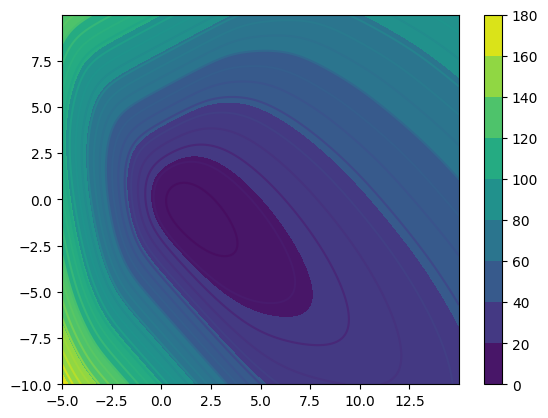

In [62]:
# phi_0 = np.arange(-100, 100, 0.2)
# phi_1 = np.arange(-100, 100, 0.2)

phi_0 = np.arange(-5, 15, 0.01)
phi_1 = np.arange(-10, 10, 0.01)

# phi = np.array([np.random.uniform(0,1), np.random.uniform(0,1)])

phi0, phi1 = np.meshgrid(phi_0, phi_1)
phi0_expanded = phi0[:, :, np.newaxis] # shape (100, 100, 1)
phi1_expanded = phi1[:, :, np.newaxis]
losses = cross_entropy_loss(x_data, y_data, model, np.array([phi0_expanded,phi1_expanded]))

filled = plt.contourf(phi0, phi1, losses)
plt.contour(phi0, phi1, losses, levels=30)
plt.colorbar(filled)
# plt.scatter(phi[0], phi[1], color="red")
plt.show

# print(cross_entropy_loss(x_data, y_data, model, phi))


In [ ]:
# gradient descent and line search for alpha